## Learning Curves:

A way to decide the number of degress of a polynomial regressor

##### Solution # 1:
cross-validation to get an estimate of a model’s generalization
performance. If a model performs well on the training data but generalizes poorly
according to the cross-validation metrics, then your model is overfitting. If it per‐
forms poorly on both, then it is underfitting

##### Solution # 2:
these are plots of the model’s per‐
formance on the training set and the validation set as a function of the training set
size (or the training iteration). To generate the plots, train the model several times on
different sized subsets of the training set. 

In [94]:
import numpy as np
from sklearn.model_selection import train_test_split
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [95]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
training_err, testing_err = [], []
model = LinearRegression()
for i in range(1, len(X_train)):
    subset_x, subset_y = X_train[:i], y_train[:i]
    model.fit(subset_x, subset_y)
    training_preds = model.predict(subset_x)
    testing_preds = model.predict(X_test)
    train_err = np.sqrt(mean_squared_error(y_train[:i], training_preds))
    test_err = np.sqrt(mean_squared_error(y_test, testing_preds))
    training_err.append(train_err)
    testing_err.append(test_err)

Text(0, 0.5, 'RMSE')

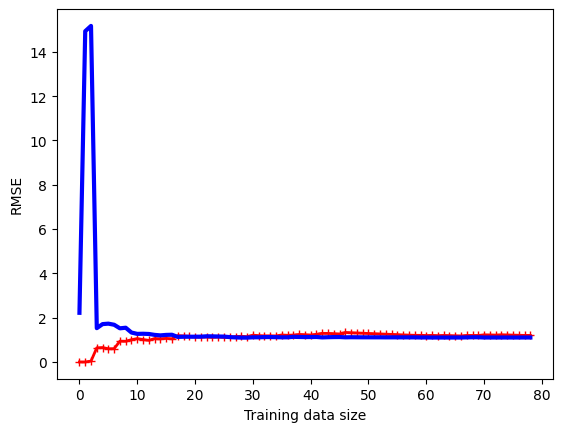

In [98]:
import matplotlib.pyplot as plt
plt.plot(training_err, "r-+", linewidth=2, label="train")
plt.plot(testing_err, "b-", linewidth=3, label="val")
plt.xlabel("Training data size")
plt.ylabel("RMSE")